<a href="https://colab.research.google.com/github/musowjanya/Deep-Learning/blob/main/VGG16(animals).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

In [ ]:
zip_file_path='/content/zip pets.zip'
extract_dir= '.'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.path.abspath(extract_dir))

/content


In [ ]:
from pathlib import Path

In [ ]:
p=Path(extract_dir)

In [ ]:
images=[]
for f in p.rglob('*'):
  # if f.is_file():
    print(f)
    images.append(f)
    # print(str(f.resolve()))

.config
dog test.webp
rat test.webp
cat test.jpg
zip pets.zip
zip pets
sample_data
.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
.config/default_configs.db
.config/gce
.config/logs
.config/.last_opt_in_prompt.yaml
.config/.last_survey_prompt.yaml
.config/.last_update_check.json
.config/configurations
.config/active_config
.config/config_sentinel
zip pets/rat2 - Copy.jpg
zip pets/cat4.jpg
zip pets/cat3.jpg
zip pets/cat5.jpg
zip pets/rat1 - Copy.jpg
zip pets/dog3.jpg
zip pets/cat1.jpeg
zip pets/dog4.jpg
zip pets/rat3.jpeg
zip pets/dog5.jpg
zip pets/dog1.jpg
zip pets/dog2.jpg
zip pets/rat5.jpg
zip pets/cat2.jpg
zip pets/rat4.jpg
sample_data/README.md
sample_data/anscombe.json
sample_data/california_housing_test.csv
sample_data/mnist_test.csv
sample_data/mnist_train_small.csv
sample_data/california_housing_train.csv
.config/logs/2026.03.23
.config/configurations/config_default
.config/logs/2026.03.23/13.29.47.572748.log
.config/logs/2026.03.23/13.29.34.829749.log
.

In [ ]:
st="abcd/rat.png"

In [ ]:
print(images)

[PosixPath('.config'), PosixPath('dog test.webp'), PosixPath('rat test.webp'), PosixPath('cat test.jpg'), PosixPath('zip pets.zip'), PosixPath('zip pets'), PosixPath('sample_data'), PosixPath('.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db'), PosixPath('.config/default_configs.db'), PosixPath('.config/gce'), PosixPath('.config/logs'), PosixPath('.config/.last_opt_in_prompt.yaml'), PosixPath('.config/.last_survey_prompt.yaml'), PosixPath('.config/.last_update_check.json'), PosixPath('.config/configurations'), PosixPath('.config/active_config'), PosixPath('.config/config_sentinel'), PosixPath('zip pets/rat2 - Copy.jpg'), PosixPath('zip pets/cat4.jpg'), PosixPath('zip pets/cat3.jpg'), PosixPath('zip pets/cat5.jpg'), PosixPath('zip pets/rat1 - Copy.jpg'), PosixPath('zip pets/dog3.jpg'), PosixPath('zip pets/cat1.jpeg'), PosixPath('zip pets/dog4.jpg'), PosixPath('zip pets/rat3.jpeg'), PosixPath('zip pets/dog5.jpg'), PosixPath('zip pets/dog1.jpg'), PosixPath('zip pets/

In [ ]:
print(type(images))
print(type(images[0]))
print(images[0])

<class 'list'>
<class 'pathlib.PosixPath'>
.config


In [ ]:
from pathlib import Path

image_dir = Path("zip pets")

images = [p for p in image_dir.rglob("*") if p.suffix.lower() in [".jpg", ".png", ".jpeg"]]

In [ ]:
print(images[:5])

[PosixPath('zip pets/rat2 - Copy.jpg'), PosixPath('zip pets/cat4.jpg'), PosixPath('zip pets/cat3.jpg'), PosixPath('zip pets/cat5.jpg'), PosixPath('zip pets/rat1 - Copy.jpg')]


In [ ]:
print(len(images))

15


In [ ]:
for img in images:
    print(img)

zip pets/rat2 - Copy.jpg
zip pets/cat4.jpg
zip pets/cat3.jpg
zip pets/cat5.jpg
zip pets/rat1 - Copy.jpg
zip pets/dog3.jpg
zip pets/cat1.jpeg
zip pets/dog4.jpg
zip pets/rat3.jpeg
zip pets/dog5.jpg
zip pets/dog1.jpg
zip pets/dog2.jpg
zip pets/rat5.jpg
zip pets/cat2.jpg
zip pets/rat4.jpg


In [ ]:
y = []

for st in images:
    s = st.name.lower()   # VERY IMPORTANT

    if 'rat' in s:
        y.append(0)
    elif 'dog' in s:
        y.append(1)
    else:
        y.append(2)

In [ ]:
for st in images:
    s = st.name.lower()
    print(s, '->', 'rat' in s)

rat2 - copy.jpg -> True
cat4.jpg -> False
cat3.jpg -> False
cat5.jpg -> False
rat1 - copy.jpg -> True
dog3.jpg -> False
cat1.jpeg -> False
dog4.jpg -> False
rat3.jpeg -> True
dog5.jpg -> False
dog1.jpg -> False
dog2.jpg -> False
rat5.jpg -> True
cat2.jpg -> False
rat4.jpg -> True


In [ ]:
print(y)

[0, 2, 2, 2, 0, 1, 2, 1, 0, 1, 1, 1, 0, 2, 0]


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

In [ ]:
label_map = {
    'cat': 0,
    'dog': 1,
    'rat': 2
}

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
X = []
y = []

for path in images:
    img = Image.open(path).convert("RGB")
    img = transform(img)
    X.append(img)

    name = path.name.lower()

    for key in label_map:
        if key in name:
            y.append(label_map[key])
            break

In [ ]:
X = torch.stack(X)
y = torch.tensor(y)

In [ ]:
model = models.vgg16(pretrained=True)

In [ ]:
model.classifier[6] = nn.Linear(4096, 3)  # 3 classes

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 5

for epoch in range(epochs):
    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 1.1766022443771362
Epoch 2, Loss: 2.203214406967163
Epoch 3, Loss: 2.1279842853546143
Epoch 4, Loss: 1.1508445739746094
Epoch 5, Loss: 1.1674001216888428


In [ ]:
import cv2

In [ ]:
ar=cv2.imread('/content/rat test.webp')

In [ ]:
ar.shape

(611, 916, 3)

In [ ]:
grar=cv2.cvtColor(ar,cv2.COLOR_BGR2GRAY)

In [ ]:
rszar=cv2.resize(grar,(28,28))

In [ ]:
far=rszar.reshape(1,1,28,28)

In [ ]:
far

array([[[[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255],
         [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255],
         [255, 255, 255, 255, 254, 255, 255, 255, 255, 255, 255, 255,
          255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
     

In [ ]:
import matplotlib.pyplot as plt

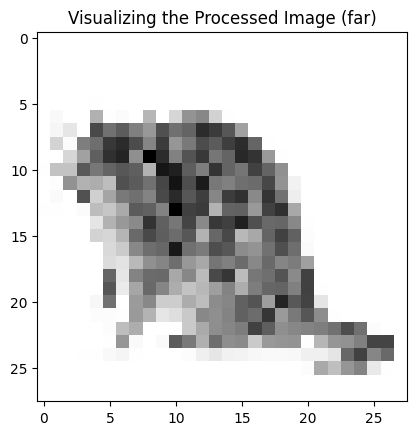

In [ ]:
plt.imshow(far.squeeze(), cmap='gray')
plt.title('Visualizing the Processed Image (far)')
plt.show()

In [ ]:
fimg = torch.from_numpy(far).float()
print(f"Shape of fimg before model call: {fimg.shape}")

Shape of fimg before model call: torch.Size([1, 1, 28, 28])


In [ ]:
import torch.nn.functional as F
# fimg is currently torch.Size([1, 1, 28, 28]) and values in [0, 255]
# 1. Scale pixel values to [0.0, 1.0]
fimg_scaled = fimg / 255.0
# 2. Replicate the single channel to three channels
fimg_3channel = fimg_scaled.repeat(1, 3, 1, 1) # Shape becomes [1, 3, 28, 28]
# 3. Resize the image to 224x224
fimg_final = F.interpolate(fimg_3channel, size=(224, 224), mode='bilinear', align_corners=False)
# Pass the processed image to the model
model(fimg_final)

tensor([[ 3.1595, -7.9880,  8.1452]], grad_fn=<AddmmBackward0>)

In [ ]:
sfx=torch.softmax(model(fimg_final),dim=1)

In [ ]:
torch.argmax(sfx,dim=1)

tensor([2])